<a href="https://colab.research.google.com/github/dmontillao/ciencia-datos-curso/blob/main/tarea_04_visualizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Parte 1 — Figura y ejes
P1. Crea una figura con plt.subplots() de tamaño 8×5.
Haz un gráfico de línea con los primeros 20 valores de sepal_length.
Agrega título "Longitud del sépalo" y etiquetas en ambos ejes.

In [5]:
df_filtro = df['sepal_length'].iloc[:20]
print(df_filtro)


0     5.1
1     4.9
2     4.7
3     4.6
4     5.0
5     5.4
6     4.6
7     5.0
8     4.4
9     4.9
10    5.4
11    4.8
12    4.8
13    4.3
14    5.8
15    5.7
16    5.4
17    5.1
18    5.7
19    5.1
Name: sepal_length, dtype: float64


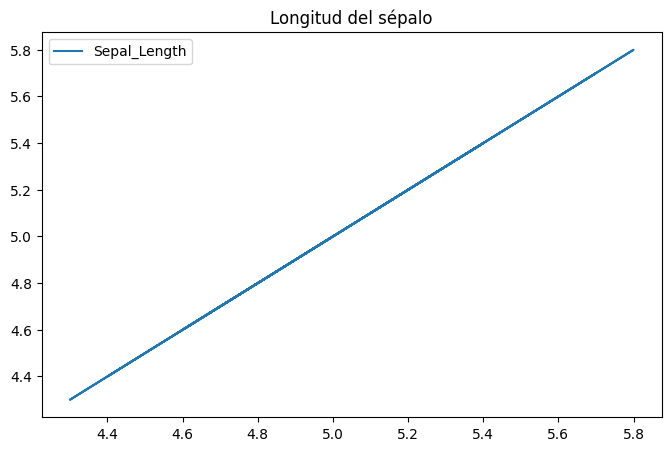

In [6]:
fig, ax = plt.subplots(figsize=(8,5 ))
ax.plot(df_filtro, df_filtro, label="Sepal_Length")
ax.set_title("Longitud del sépalo")
ax.legend()
plt.show()

Parte 2 — Gráfico de barras
P2. Calcula el promedio de petal_length por especie (species) y guárdalo en una variable.
Luego crea un gráfico de barras vertical con esos promedios.
Agrega título y etiquetas en ambos ejes.

(array([0, 1, 2]),
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

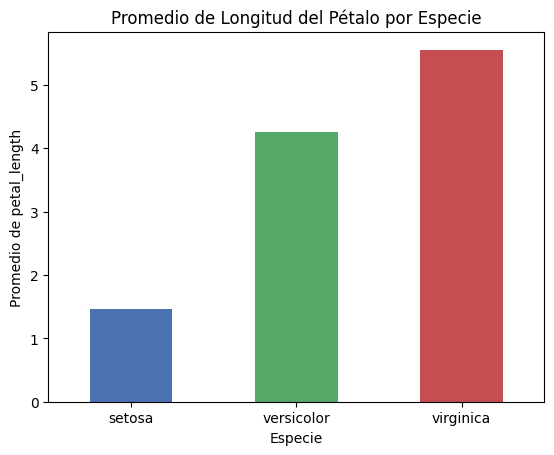

In [8]:
promedios_especie = df.groupby('species')['petal_length'].mean()

promedios_especie.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])

plt.title('Promedio de Longitud del Pétalo por Especie')
plt.xlabel('Especie')
plt.ylabel('Promedio de petal_length')
plt.xticks(rotation=0)

Parte 3 — Dispersión (scatter plot)
P3. Crea un gráfico de dispersión (scatter) con sepal_length en el eje X y sepal_width en el eje Y.
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).
Agrega leyenda, título y etiquetas.

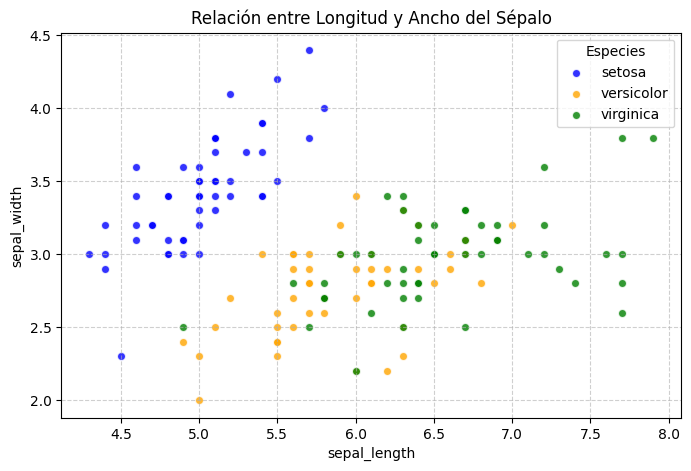

In [12]:
especies = df["species"].unique()
colores = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

for i, especie in enumerate(especies):
    df_especie = df[df['species'] == especie]

    plt.scatter(
        df_especie['sepal_length'],
        df_especie['sepal_width'],
        label=especie,
        color=colores[i],
        edgecolor='w',
        alpha=0.8
    )

plt.title('Relación entre Longitud y Ancho del Sépalo')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend(title='Especies')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()





Parte 4 — Histograma
P4. Crea un histograma de la columna petal_width con 15 bins.
Agrega una línea vertical punteada en el valor de la media con ax.axvline().
Agrega título y etiquetas.

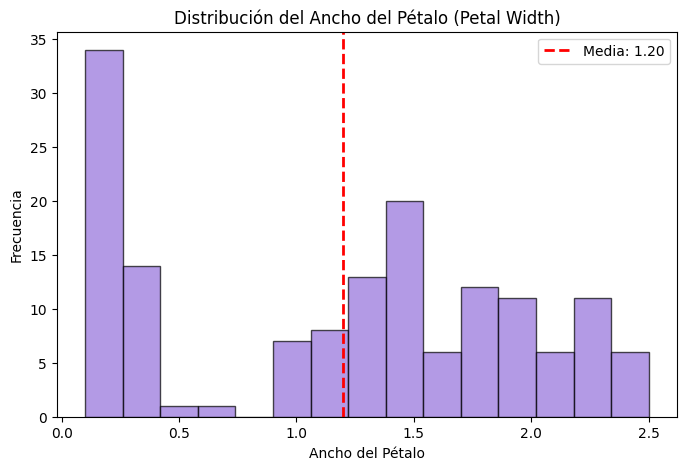

In [13]:
media_petal_width = df['petal_width'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['petal_width'], bins=15, color='mediumpurple', edgecolor='black', alpha=0.7)

ax.axvline(media_petal_width, color='red', linestyle='--', linewidth=2, label=f'Media: {media_petal_width:.2f}')

ax.set_title('Distribución del Ancho del Pétalo (Petal Width)')
ax.set_xlabel('Ancho del Pétalo')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.show()

Parte 5 — Guardar figura
P5. Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en output/promedios_iris.png.
Usa dpi=100 y bbox_inches="tight".

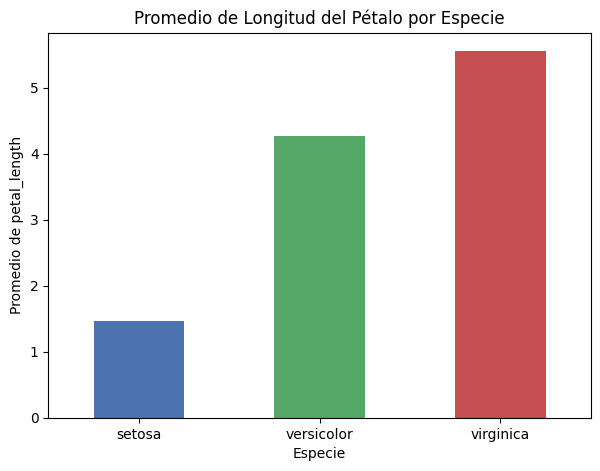

In [15]:
promedios_especie = df.groupby('species')['petal_length'].mean()

plt.figure(figsize=(7, 5))
promedios_especie.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'])

plt.title('Promedio de Longitud del Pétalo por Especie')
plt.xlabel('Especie')
plt.ylabel('Promedio de petal_length')
plt.xticks(rotation=0)

if not os.path.exists('output'):
    os.makedirs('output')

plt.savefig(
    'output/promedios_iris.png',
    dpi=100,
    bbox_inches='tight'
)